In [1]:
import pandas as pd

In [2]:
### reading the csv: FrogID5_dataset
filename = "../data/raw/FrogID5_dataset.csv"

# load the relevant columns only (others are either empty, contail all the same information or contain irrelevant information)
columns_to_load_frogID = [
    'occurrenceID', 'eventID', 'decimalLatitude', 'decimalLongitude', 'scientificName',
    'eventDate', 'eventTime', 'coordinateUncertaintyInMeters', 'geoprivacy', 'recordedBy', 'stateProvince'
]

frogID5_database_original = pd.read_csv(filename, usecols=columns_to_load_frogID, sep=',', on_bad_lines='skip')

frogID5_database_edited = frogID5_database_original.rename(columns={'stateProvince': 'stateProvinceShort'})
frogID5_database_edited

,occurrenceID,eventID,decimalLatitude,decimalLongitude,scientificName,eventDate,eventTime,coordinateUncertaintyInMeters,geoprivacy,recordedBy,stateProvinceShort
0,1,4493,-38.1000,144.600,Limnodynastes peronii,2017-11-14,11:49:20UTC,10000.000000,obscured,3817,VIC
1,2,4496,-17.0000,145.700,Litoria rheocola,2017-11-14,12:18:49UTC,10000.000000,obscured,1595,QLD
2,3,4503,-17.0000,145.700,Litoria dayi,2017-11-14,12:43:09UTC,10000.000000,obscured,1595,QLD
3,4,5349,-38.1000,144.600,Limnodynastes peronii,2017-11-18,21:45:45UTC,10000.000000,obscured,4558,VIC
4,5,5603,-38.1000,144.600,Limnodynastes peronii,2017-11-18,11:01:17UTC,10000.000000,obscured,3817,VIC
...,...,...,...,...,...,...,...,...,...,...,...
771537,771538,283438,-31.9335,115.912,Litoria adelaidensis,2019-10-13,19:14:00+0800,899.999023,open,13928,WA
771538,771539,283462,-31.9335,115.912,Litoria adelaidensis,2019-09-28,18:22:31+0800,1000.000000,open,13928,WA
771539,771540,385997,-33.3263,151.448,Litoria gracilenta,2022-02-26,21:31:52+1100,2800.000000,open,8433,NSW
771540,771541,442368,-31.9340,115.914,Litoria adelaidensis,2022-09-10,18:18:32+0800,600.000000,open,13928,WA


In [3]:
### extending the FrogID5_dataset with the vernacular names of the species

## webscraping a table that contains scientific and venacular names of australian amphibia
url = "https://amphibiaweb.org/cgi-bin/amphib_query?query_src=aw_maps_geo-ocea&rel-isocc=like&orderbyaw=Order&where-isocc=Australia"
List_of_amphibia_species_of_Australia  = pd.read_html(url)
amphibia_of_australia = List_of_amphibia_species_of_Australia[1]

## cleaning data: drop rows that only contain NaN, reset_index, choose only important columns, renaming columns
amphibia_of_australia_cleaned = amphibia_of_australia.dropna(how='all').reset_index()
 
## merging the amphibia dataframe with the FrogID5_dataset
frogID5_database_edited = pd.merge(frogID5_database_edited, amphibia_of_australia_cleaned, on='scientificName', how='left')

In [4]:
### extending the FrogID5_dataset with the full state / territory names

## webscraping a table that contains all australian states and territories and its short forms
url = "https://en.wikipedia.org/wiki/States_and_territories_of_Australia"
States_and_territories_of_Australia = pd.read_html(url, header=0)
states_and_territories = States_and_territories_of_Australia[9]

## cleaning data: dropping irrelevant rows, selecting important columns, renaming columns
indices_to_drop = [0, 9, 10, 11, 12, 13, 14]
states_and_territories = states_and_territories.drop(indices_to_drop).reset_index()[['Postal', 'State/territory']]
states_and_territories = states_and_territories.rename(columns={'Postal': 'stateProvinceShort', 'State/territory': 'stateProvince'})

## merging the stateProvinces dataframe with the FrogID5_dataset
frogID5_database_edited = pd.merge(frogID5_database_edited, states_and_territories, on='stateProvinceShort', how='left')

In [5]:
### extending the FrogID5_dataset with columns for year, month and day of the event date

frogID5_database_edited[['year', 'month', 'day']] = frogID5_database_edited['eventDate'].str.split('-', expand=True)

In [6]:
### saving the edited database as a csv file

frogID5_database_final = frogID5_database_edited
frogID5_database_final.to_csv('../data/processed/frogID5_database_prepared.csv', index=False)

In [7]:
filename = "../data/processed/frogID5_database_prepared.csv"
frogID5_database_final = pd.read_csv(filename, sep=',', on_bad_lines='skip')

In [8]:
### preparing data
year_month_counts = frogID5_database_final.groupby(['year', 'month']).size().reset_index(name='counts')
year_month_counts['eventMonth'] = year_month_counts['month'].astype(str) + '/' + year_month_counts['year'].astype(str)
year_month_counts['eventMonth'] = pd.to_datetime(year_month_counts['eventMonth'], format='%m/%Y')
year_month_counts = year_month_counts.set_index('eventMonth')[['counts']]

year_month_counts#.head(60)

,counts
eventMonth,
2017-11-01,7416
2017-12-01,5746
2018-01-01,4669
2018-02-01,3750
2018-03-01,2450
...,...
2022-07-01,9211
2022-08-01,16838
2022-09-01,36047


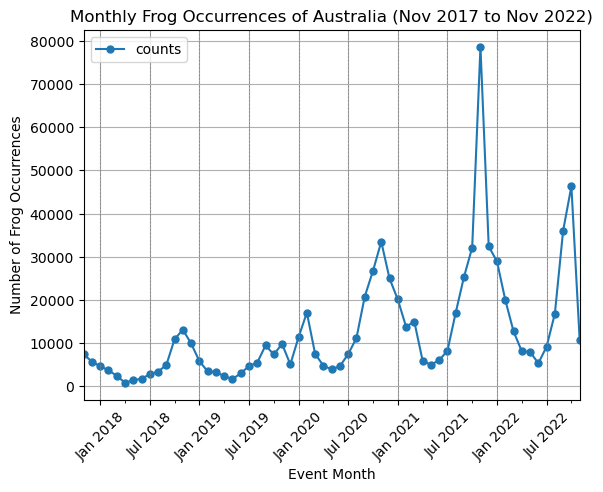

In [9]:
import matplotlib.pyplot as plt

# plotting
monthly_counts_by_state_territory_plot = year_month_counts.plot(marker='o', markersize=5)

# Vertikale Gitterlinien hinzufügen
start_date = year_month_counts.index.min().to_period('M').to_timestamp()
end_date = year_month_counts.index.max().to_period('M').to_timestamp()


monthly_counts_by_state_territory_plot.grid(True)

ticks = []
tick_labels = []
current_date = start_date

while current_date <= end_date:
    if current_date.month == 1 or current_date.month == 7:
        monthly_counts_by_state_territory_plot.axvline(current_date, color='gray', linestyle='--', linewidth=0.5)
        ticks.append(current_date)
        tick_labels.append(current_date.strftime('%b %Y'))
    current_date += pd.DateOffset(months=1)

# Ticks und Labels setzen
monthly_counts_by_state_territory_plot.set_xticks(ticks)
monthly_counts_by_state_territory_plot.set_xticklabels(tick_labels, rotation=45)

# Titel und Achsenbeschriftungen setzen
monthly_counts_by_state_territory_plot.set_title('Monthly Frog Occurrences of Australia (Nov 2017 to Nov 2022)')
monthly_counts_by_state_territory_plot.set_xlabel('Event Month')
monthly_counts_by_state_territory_plot.set_ylabel('Number of Frog Occurrences')

plt.show()

In [10]:
filename = "../data/processed/frogID5_database_prepared.csv"
frogID5_database_final = pd.read_csv(filename, sep=',', on_bad_lines='skip')

In [11]:
### preparing data

species_counts = frogID5_database_final.groupby('vernacularName').size().reset_index(name='counts')
species_counts = species_counts.sort_values(by='counts', ascending=False).set_index('vernacularName')

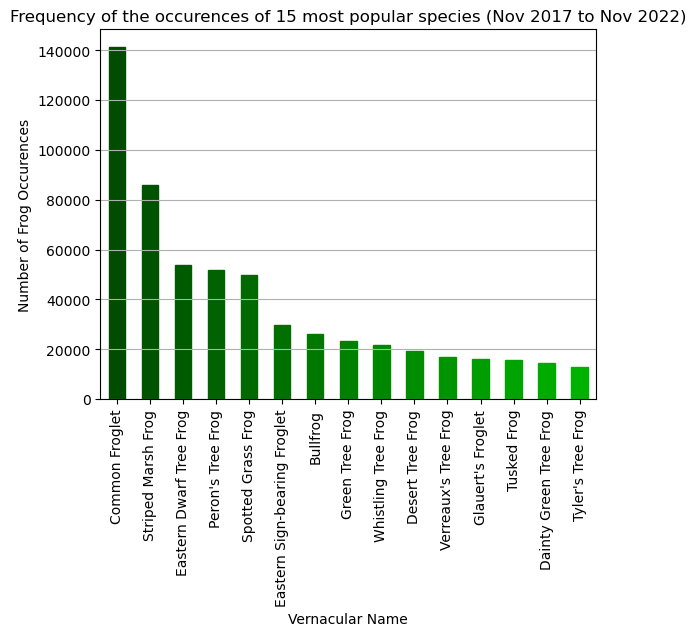

In [12]:
### plotting

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

number_of_bars = 15


frequency_of_most_popular_species  = species_counts.head(number_of_bars).plot(kind='bar')

frequency_of_most_popular_species.set_title('Frequency of the occurences of ' + str(number_of_bars) + ' most popular species (Nov 2017 to Nov 2022)')
frequency_of_most_popular_species.set_xlabel('Vernacular Name')
frequency_of_most_popular_species.set_ylabel('Number of Frog Occurences')

frequency_of_most_popular_species.get_legend().remove()
frequency_of_most_popular_species.grid(True, axis='y')

## coloring the bars
green_shading = []
for i in range(number_of_bars):
    v = 0.3 + (0.4 * (i / (number_of_bars - 1)))
    green_shading.append(mcolors.to_hex(mcolors.hsv_to_rgb((1/3, 1, v))))

bars = frequency_of_most_popular_species.patches
for i in range(len(bars)):
    bars[i].set_color(green_shading[i])  


plt.show()

In [13]:
filename = "../data/processed/frogID5_database_prepared.csv"
frogID5_database_final = pd.read_csv(filename, sep=',', on_bad_lines='skip')

In [14]:
### preparing data

monthly_frogs_by_state = frogID5_database_final.groupby(['month', 'stateProvince']).size().reset_index(name='counts')
pivot_table = monthly_frogs_by_state.pivot(index='month', columns='stateProvince', values='counts')

## excluding the stateProvinces that have under 50000 recordings in total
stateProvince_counts = frogID5_database_final.groupby('stateProvince').size().reset_index(name='counts')
stateProvinces_list_to_exclude = stateProvince_counts[stateProvince_counts['counts'] < 50000]['stateProvince'].tolist()
filtered_frogs_by_state = pivot_table.drop(columns=stateProvinces_list_to_exclude)

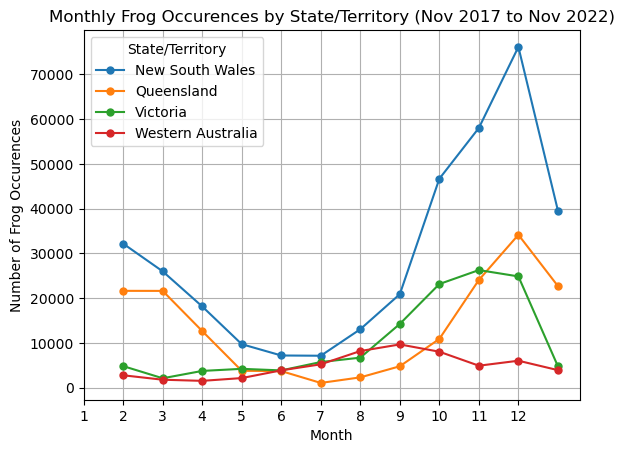

In [15]:
import matplotlib.pyplot as plt

# plotting
monthly_counts_by_state_territory_plot = filtered_frogs_by_state.plot(marker='o', markersize=5)

monthly_counts_by_state_territory_plot.set_title('Monthly Frog Occurences by State/Territory (Nov 2017 to Nov 2022)')
monthly_counts_by_state_territory_plot.set_xlabel('Month')
monthly_counts_by_state_territory_plot.set_ylabel('Number of Frog Occurences')

monthly_counts_by_state_territory_plot.legend(title='State/Territory')
monthly_counts_by_state_territory_plot.grid(True)

# adding more horizontal stripes and adding even numbers to x-axis
months = filtered_frogs_by_state.index.astype(int)
monthly_counts_by_state_territory_plot.set_xticks(range(12))
monthly_counts_by_state_territory_plot.set_xticklabels(months)

plt.show()

In [16]:
filename = "../data/processed/frogID5_database_prepared.csv"
frogID5_database_final = pd.read_csv(filename, sep=',', on_bad_lines='skip')

In [18]:
### showing general distribution of frogs in australia (different color for states)

import folium

sample_size = 1000

unique_states = frogID5_database_final['stateProvince'].dropna().unique()
colors = ['blue', 'red', 'green', 'purple', 'orange', 'darkred', 'lightred', 'yellow', 'brown']

frog_in_states_map = folium.Map(location=[-27, 133], zoom_start=4)

# adding CircleMarkers for every stateProvince
for i in range(len(unique_states)):
    state_data = frogID5_database_final[frogID5_database_final['stateProvince'] == unique_states[i]]
    
    if len(state_data) >= sample_size:
        sample_data = state_data.sample(sample_size)
    else:
        sample_data = state_data
    
    for idx, row in sample_data.iterrows():
        folium.CircleMarker(
            location=[row['decimalLatitude'], row['decimalLongitude']],
            radius=1,
            color=colors[i], 
            fill=True,
            fill_color=colors[i],
            fill_opacity=1
        ).add_to(frog_in_states_map)

# Setze die Begrenzungskoordinaten für Australien
bounds = [[-44, 112], [-10, 154]] 
frog_in_states_map.fit_bounds(bounds)

frog_in_states_map